We assume Poisson arrivals and exponential service as a first-order approximation of signal-controlled traffic. Under steady-state conditions, queue length follows a geometric distribution.

In real Indian traffic, bursty arrivals and signal cycles may lead to heavier tails than predicted by this model.

Case 1: ρ = 0.6 (off-peak)

Case 2: ρ = 0.9 (peak hour)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lambda_i = 4.0      # arrival rate
mu_i = 6.0          # service rate (must be > lambda_i)
rho_i = lambda_i / mu_i
num_samples = 200000
beta = 0.5          # risk weight

np.random.seed(42)

The Data for this simulation is generated randomly as of now.
The accurate simulations are yet to be done.

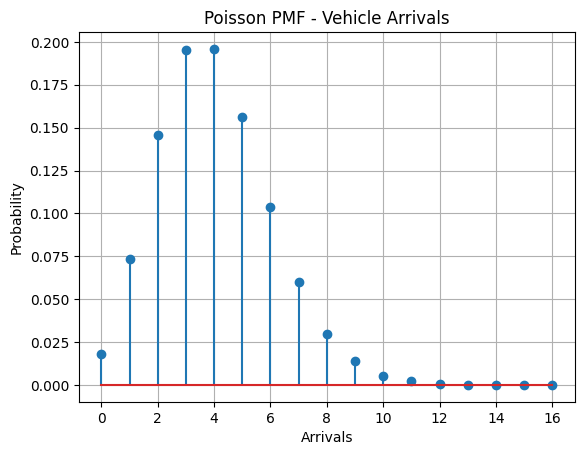

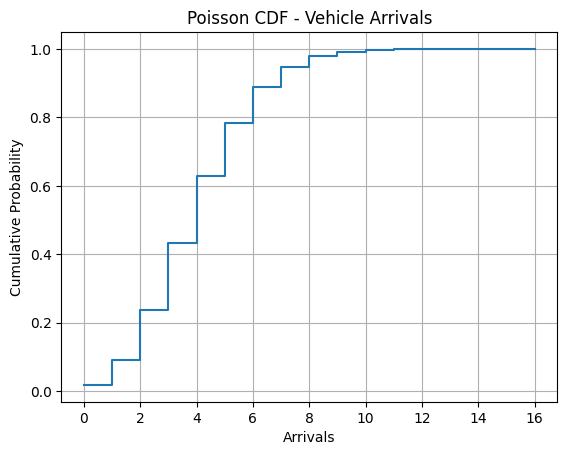

In [ ]:
# 1) POISSON ARRIVALS

poisson_samples = np.random.poisson(lambda_i, num_samples)

values_p, counts_p = np.unique(poisson_samples, return_counts=True)
pmf_p = counts_p / num_samples
cdf_p = np.cumsum(pmf_p)

plt.figure()
plt.stem(values_p, pmf_p)
plt.title("Poisson PMF - Vehicle Arrivals")
plt.xlabel("Arrivals")
plt.ylabel("Probability")
plt.grid()
plt.show()

plt.figure()
plt.step(values_p, cdf_p, where='post')
plt.title("Poisson CDF - Vehicle Arrivals")
plt.xlabel("Arrivals")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()

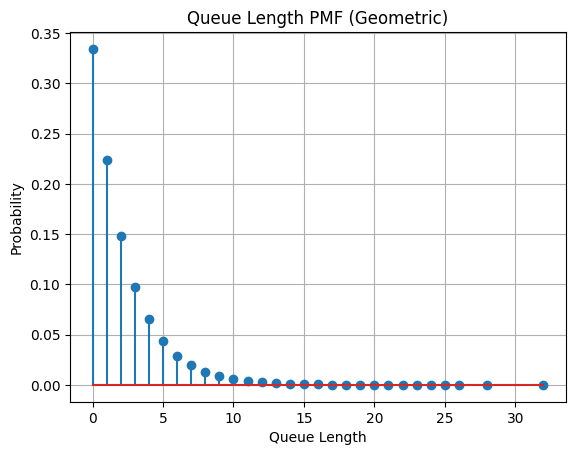

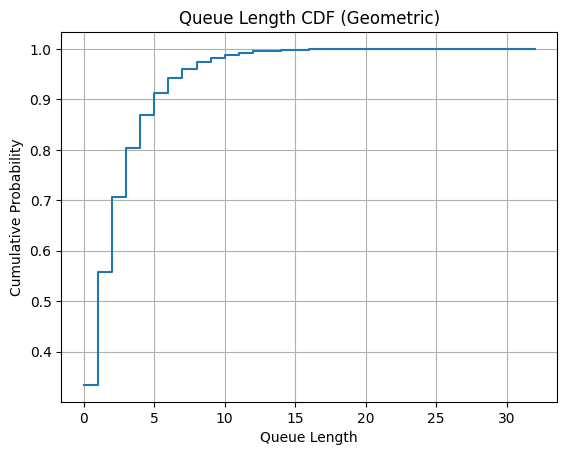

In [ ]:
# 2) GEOMETRIC QUEUE LENGTH

geom_samples = np.random.geometric(p=1-rho_i, size=num_samples) - 1

values_q, counts_q = np.unique(geom_samples, return_counts=True)
pmf_q = counts_q / num_samples
cdf_q = np.cumsum(pmf_q)

plt.figure()
plt.stem(values_q, pmf_q)
plt.title("Queue Length PMF (Geometric)")
plt.xlabel("Queue Length")
plt.ylabel("Probability")
plt.grid()
plt.show()

plt.figure()
plt.step(values_q, cdf_q, where='post')
plt.title("Queue Length CDF (Geometric)")
plt.xlabel("Queue Length")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()


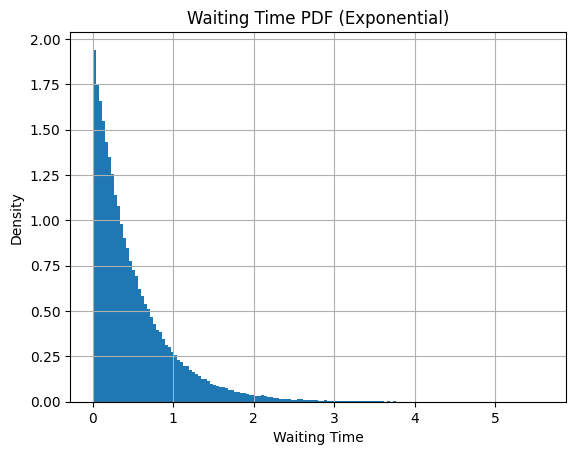

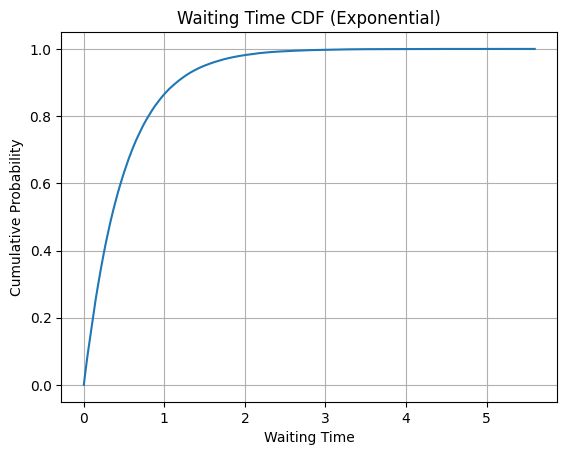

In [ ]:
# 3) EXPONENTIAL WAITING TIME

rate = mu_i - lambda_i
exp_samples = np.random.exponential(scale=1/rate, size=num_samples)

plt.figure()
plt.hist(exp_samples, bins=150, density=True)
plt.title("Waiting Time PDF (Exponential)")
plt.xlabel("Waiting Time")
plt.ylabel("Density")
plt.grid()
plt.show()

sorted_exp = np.sort(exp_samples)
cdf_exp = np.arange(1, num_samples+1) / num_samples

plt.figure()
plt.plot(sorted_exp, cdf_exp)
plt.title("Waiting Time CDF (Exponential)")
plt.xlabel("Waiting Time")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()

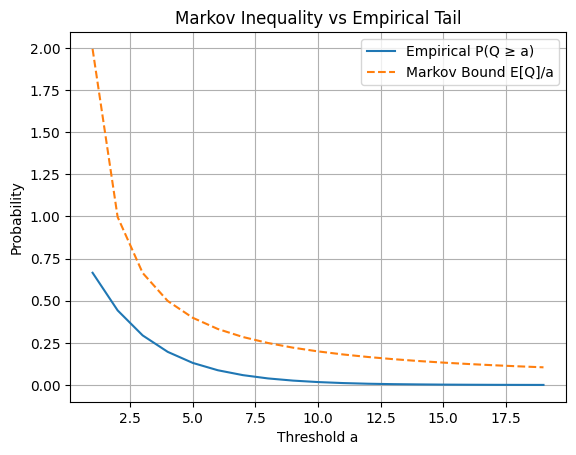

In [ ]:
# 4) MARKOV INEQUALITY VERIFICATION

a_values = np.arange(1, 20)
empirical_tail = []
markov_bound = []

E_Q = np.mean(geom_samples)

for a in a_values:
    empirical_prob = np.mean(geom_samples >= a)
    empirical_tail.append(empirical_prob)
    markov_bound.append(E_Q / a)

plt.figure()
plt.plot(a_values, empirical_tail, label="Empirical P(Q ≥ a)")
plt.plot(a_values, markov_bound, linestyle='--', label="Markov Bound E[Q]/a")
plt.title("Markov Inequality vs Empirical Tail")
plt.xlabel("Threshold a")
plt.ylabel("Probability")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 5) JENSEN INEQUALITY VERIFICATION

E_Q2 = np.mean(geom_samples**2)
lhs = E_Q2
rhs = (E_Q)**2

print("Jensen Verification:")
print("E[Q^2] =", lhs)
print("(E[Q])^2 =", rhs)
print("Inequality holds:", lhs >= rhs)

Jensen Verification:
E[Q^2] = 9.97698
(E[Q])^2 = 3.9746801956
Inequality holds: True


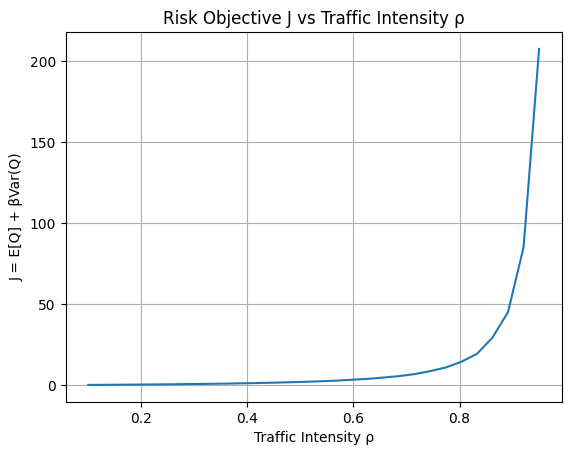

In [ ]:
# 6) RISK OBJECTIVE vs TRAFFIC INTENSITY

rho_values = np.linspace(0.1, 0.95, 30)
J_values = []

for rho in rho_values:
    samples = np.random.geometric(p=1-rho, size=50000) - 1
    J = np.mean(samples) + beta*np.var(samples)
    J_values.append(J)

plt.figure()
plt.plot(rho_values, J_values)
plt.title("Risk Objective J vs Traffic Intensity ρ")
plt.xlabel("Traffic Intensity ρ")
plt.ylabel("J = E[Q] + βVar(Q)")
plt.grid()
plt.show()